In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
import pingouin as pg
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from sklearn.linear_model import LassoCV, RidgeCV, Lasso
import matplotlib.cm as cm
%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

# 1 Load data from "2 BrainAge"

In [98]:
# load data from pickle and convert to dataframe
# brain_test = pd.read_pickle("2_brain_test.pkl")
# brain_train = pd.read_pickle("2_brain_train.pkl")
main_test = pd.read_pickle("2_main_test.pkl")
main_train = pd.read_pickle("2_main_train.pkl")
# brain_test = pd.DataFrame(brain_test)
# brain_train = pd.DataFrame(brain_train)
main_test = pd.DataFrame(main_test)
main_train = pd.DataFrame(main_train)

# 2 Basic distributions

## 2.1 Data and Descriptives

In [99]:
main_test.head()

,ID,Age,Gender,TPA,VPA,MPA,MVPA,LPA,BMI,SRLPA,SRMPA,SRVPA,FI,HG,IS,HR,JPA,DBP,SBP,BADA2009,BADASEG,BADDesikan
10,1001365,71.0,Female,3396.9600,20.1600,514.0800,554.4000,2862.7200,28.2030,594.0,240.0,240.0,5.0,20.0,11025,73.0,NaN,70.0,106.0,-4.083941,-6.164178,1.498266
17,1001748,48.0,Female,3126.8160,265.3056,596.9376,1127.5488,2264.5728,25.7857,462.0,0.0,2400.0,8.0,34.0,11025,52.0,NaN,75.0,124.0,4.278380,-2.095410,-4.178806
20,1001984,69.0,Female,2468.4192,9.9936,579.6288,599.6160,1878.7968,25.7422,693.0,960.0,0.0,7.0,26.0,11026,76.0,NaN,79.0,120.0,-0.194364,-4.009665,4.345633
21,1002138,56.0,Female,2465.2224,29.1168,427.0464,485.2800,2009.0592,33.5680,2970.0,720.0,240.0,NaN,18.0,11025,56.0,Sometimes,75.0,134.0,-4.649129,-10.866188,20.605834
23,1002288,63.0,Female,2559.7728,109.1376,704.4336,922.7088,1746.2016,27.4762,264.0,960.0,0.0,5.0,30.0,11025,85.0,NaN,84.0,146.0,-5.524329,-4.390247,13.802266


In [100]:
print(main_test.shape)
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
print(main_test.shape)

(5985, 22)
(5422, 22)


### 2.1.1 Test set

In [101]:
female = main_test[main_test["Gender"] == "Female"]
male = main_test[main_test["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:",male.shape[0])

print("Age")
mean = female["Age"].mean()
print("Female", mean)
std = female["Age"].std()
print("Female",std)
mean = male["Age"].mean()
print("Male",mean)
std = male["Age"].std()
print("Male",std)

print("LPA")
mean = female["LPA"].mean()
print("Female", mean)
std = female["LPA"].std()
print("Female",std)
mean = male["LPA"].mean()
print("Male",mean)
std = male["LPA"].std()
print("Male",std)

print("MPA")
mean = female["MPA"].mean()
print("Female", mean)
std = female["MPA"].std()
print("Female",std)
mean = male["MPA"].mean()
print("Male",mean)
std = male["MPA"].std()
print("Male",std)

print("VPA")
mean = female["VPA"].mean()
print("Female", mean)
std = female["VPA"].std()
print("Female",std)
mean = male["VPA"].mean()
print("Male",mean)
std = male["VPA"].std()
print("Male",std)

print("TPA")
mean = female["TPA"].mean()
print("Female", mean)
std = female["TPA"].std()
print("Female",std)
mean = male["TPA"].mean()
print("Male",mean)
std = male["TPA"].std()
print("Male",std)

print("BMI")
mean = female["BMI"].mean()
print("Female", mean)
std = female["BMI"].std()
print("Female",std)
mean = male["BMI"].mean()
print("Male",mean)
std = male["BMI"].std()
print("Male",std)

print("HG")
mean = female["HG"].mean()
print("Female", mean)
std = female["HG"].std()
print("Female",std)
mean = male["HG"].mean()
print("Male",mean)
std = male["HG"].std()
print("Male",std)

print("HR")
mean = female["HR"].mean()
print("Female", mean)
std = female["HR"].std()
print("Female",std)
mean = male["HR"].mean()
print("Male",mean)
std = male["HR"].std()
print("Male",std)

print("SRLPA")
mean = female["SRLPA"].mean()
print("Female", mean)
std = female["SRLPA"].std()
print("Female",std)
mean = male["SRLPA"].mean()
print("Male",mean)
std = male["SRLPA"].std()
print("Male",std)

print("SRMPA")
mean = female["SRMPA"].mean()
print("Female", mean)
std = female["SRMPA"].std()
print("Female",std)
mean = male["SRMPA"].mean()
print("Male",mean)
std = male["SRMPA"].std()
print("Male",std)

print("SRVPA")
mean = female["SRVPA"].mean()
print("Female", mean)
std = female["SRVPA"].std()
print("Female",std)
mean = male["SRVPA"].mean()
print("Male",mean)
std = male["SRVPA"].std()
print("Male",std)

print("FI")
mean = female["FI"].mean()
print("Female", mean)
std = female["FI"].std()
print("Female",std)
mean = male["FI"].mean()
print("Male",mean)
std = male["FI"].std()
print("Male",std)

print("DBP")
mean = female["DBP"].mean()
print("Female", mean)
std = female["DBP"].std()
print("Female",std)
mean = male["DBP"].mean()
print("Male",mean)
std = male["DBP"].std()
print("Male",std)

print("SBP")
mean = female["SBP"].mean()
print("Female", mean)
std = female["SBP"].std()
print("Female",std)
mean = male["SBP"].mean()
print("Male",mean)
std = male["SBP"].std()
print("Male",std)

Number of females: 2898
NUmber of males: 2524
Age
Female 63.49482401656315
Female 7.556813291182583
Male 65.49207606973059
Male 7.824543474679913
LPA
Female 2056.1930434782607
Female 406.8644273491336
Male 1885.7437103011096
Male 405.84204331256376
MPA
Female 498.95904596273294
Female 226.04598507597225
Male 467.3088513470682
Male 219.2158898210811
VPA
Female 31.376486956521767
Female 41.49015419937569
Male 36.690498256735374
Male 47.658656646516
TPA
Female 2586.5285763975157
Female 549.9034889901462
Male 2389.743059904913
Male 544.1004962557213
BMI
Female 25.811531090407172
Female 4.5080781213825105
Male 26.943885657686213
Male 3.8018138925908085
HG
Female 26.233954451345756
Female 6.490942652213226
Male 42.08320126782884
Male 8.649252170729214
HR
Female 69.11076604554866
Female 10.061554495925744
Male 66.68621236133121
Male 11.241229111720902
SRLPA
Female 788.5644927536232
Female 716.9490442462906
Male 753.3099841521395
Male 709.4481511450006
SRMPA
Female 658.1545893719807
Female 770

### 2.1.2 Train set

In [102]:
female = main_train[main_train["Gender"] == "Female"]
male = main_train[main_train["Gender"]== "Male"]

print(female.shape)
print(male.shape)

print("Age")
mean = female["Age"].mean()
print("Female", mean)
std = female["Age"].std()
print("Female",std)
mean = male["Age"].mean()
print("Male",mean)
std = male["Age"].std()
print("Male",std)

print("SRLPA")
mean = female["SRLPA"].mean()
print("Female", mean)
std = female["SRLPA"].std()
print("Female",std)
mean = male["SRLPA"].mean()
print("Male",mean)
std = male["SRLPA"].std()
print("Male",std)

print("SRMPA")
mean = female["SRMPA"].mean()
print("Female", mean)
std = female["SRMPA"].std()
print("Female",std)
mean = male["SRMPA"].mean()
print("Male",mean)
std = male["SRMPA"].std()
print("Male",std)

print("SRVPA")
mean = female["SRVPA"].mean()
print("Female", mean)
std = female["SRVPA"].std()
print("Female",std)
mean = male["SRVPA"].mean()
print("Male",mean)
std = male["SRVPA"].std()
print("Male",std)

print("BMI")
mean = female["BMI"].mean()
print("Female", mean)
std = female["BMI"].std()
print("Female",std)
mean = male["BMI"].mean()
print("Male",mean)
std = male["BMI"].std()
print("Male",std)

print("FI")
mean = female["FI"].mean()
print("Female", mean)
std = female["FI"].std()
print("Female",std)
mean = male["FI"].mean()
print("Male",mean)
std = male["FI"].std()
print("Male",std)

print("DBP")
mean = female["DBP"].mean()
print("Female", mean)
std = female["DBP"].std()
print("Female",std)
mean = male["DBP"].mean()
print("Male",mean)
std = male["DBP"].std()
print("Male",std)

print("SBP")
mean = female["SBP"].mean()
print("Female", mean)
std = female["SBP"].std()
print("Female",std)
mean = male["SBP"].mean()
print("Male",mean)
std = male["SBP"].std()
print("Male",std)

print("HG")
mean = female["HG"].mean()
print("Female", mean)
std = female["HG"].std()
print("Female",std)
mean = male["HG"].mean()
print("Male",mean)
std = male["HG"].std()
print("Male",std)

print("HR")
mean = female["HR"].mean()
print("Female", mean)
std = female["HR"].std()
print("Female",std)
mean = male["HR"].mean()
print("Male",mean)
std = male["HR"].std()
print("Male",std)

(8464, 14)
(8500, 14)
Age
Female 63.5430056710775
Female 7.532938783645655
Male 64.8970588235294
Male 7.7473407032087644
SRLPA
Female 979.4488894139887
Female 1030.2682504887787
Male 931.368705882353
Male 1010.6344243048728
SRMPA
Female 837.0694706994329
Female 1108.2106032899997
Male 825.4564705882353
Male 1142.6415545525
SRVPA
Female 572.390359168242
Female 911.0747781380226
Male 744.6136470588235
Male 1155.662068357008
BMI
Female 26.093124905482046
Female 4.566816456359102
Male 27.17897574117647
Male 3.7638577977923573
FI
Female 6.59026369168357
Female 1.9955481510602957
Male 6.842503022974607
Male 2.067864630267394
DBP
Female 79.24031190926276
Female 10.223065703736285
Male 83.40529411764706
Male 10.092097153886822
SBP
Female 132.40441871455576
Female 18.966623279388635
Male 140.34941176470588
Male 17.455823072976433
HG
Female 26.03804347826087
Female 6.352348209894286
Male 42.54270588235294
Male 8.712799311334651
HR
Female 69.02611058601134
Female 10.33595673376813
Male 66.8181176

## 2.3 Age and BrainAge

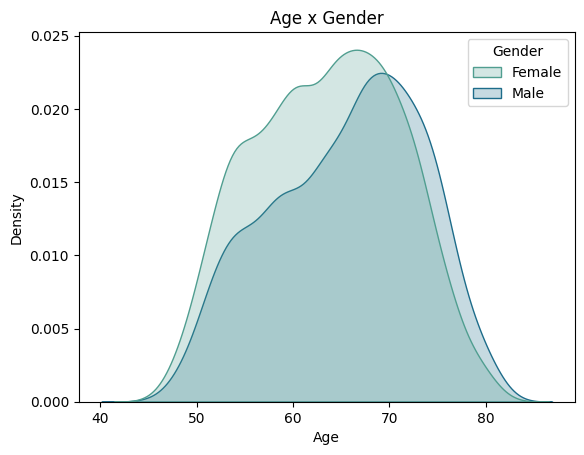

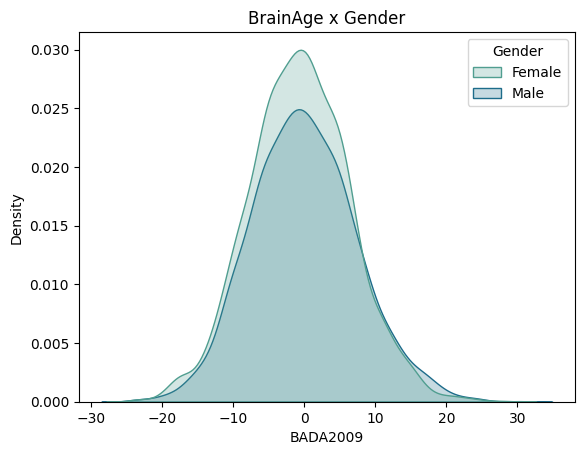

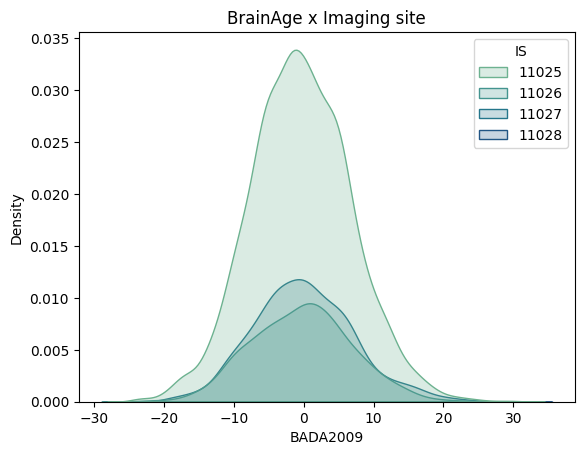

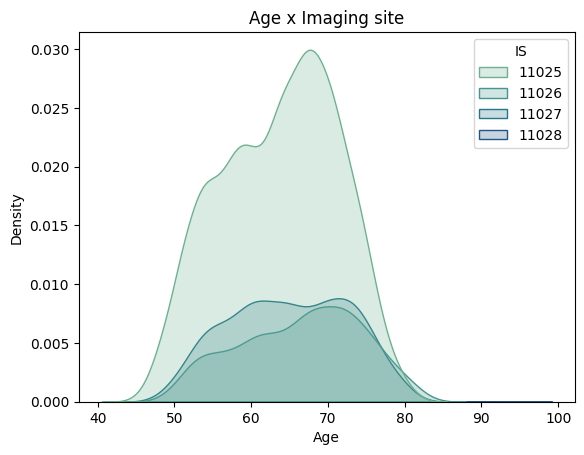

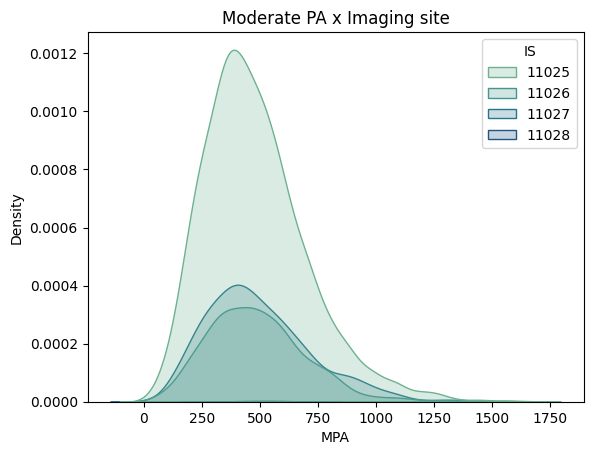

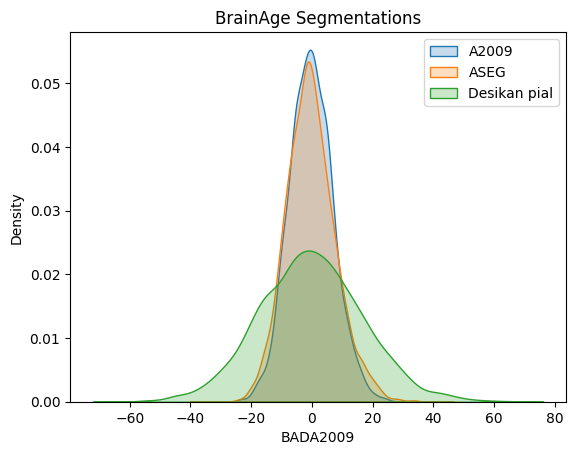

In [103]:
plt.figure()
sns.kdeplot(data = main_test, x= 'Age', hue = 'Gender', fill=True, palette = "crest")
plt.title("Age x Gender")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'Gender', fill=True, palette = "crest")
plt.title("BrainAge x Gender")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'IS', fill=True, palette = "crest")
plt.title("BrainAge x Imaging site")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'Age', hue = 'IS', fill=True, palette = "crest")
plt.title("Age x Imaging site")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'MPA', hue = 'IS', fill=True, palette = "crest")
plt.title("Moderate PA x Imaging site")
plt.show()


plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', fill=True, label="A2009")
sns.kdeplot(data = main_test, x= 'BADASEG', fill=True, label="ASEG")
sns.kdeplot(data = main_test, x= 'BADDesikan', fill=True, label="Desikan pial")
plt.title("BrainAge Segmentations")
plt.legend()
plt.show()

## 2.4 Physical activity

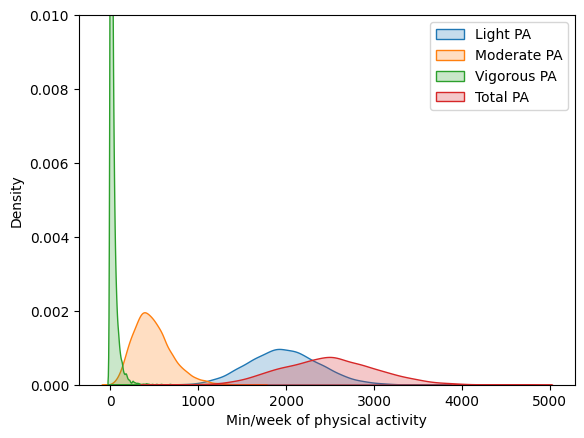

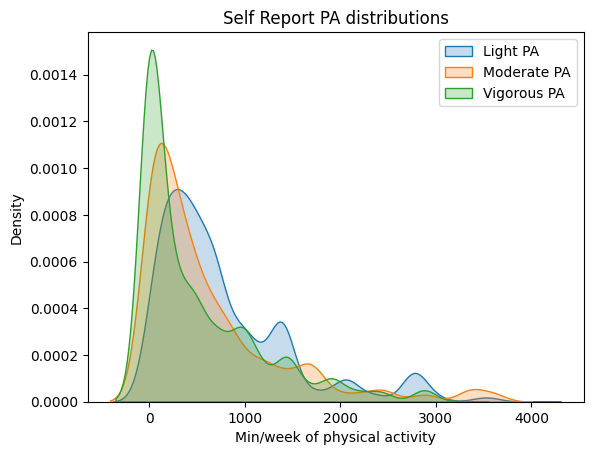

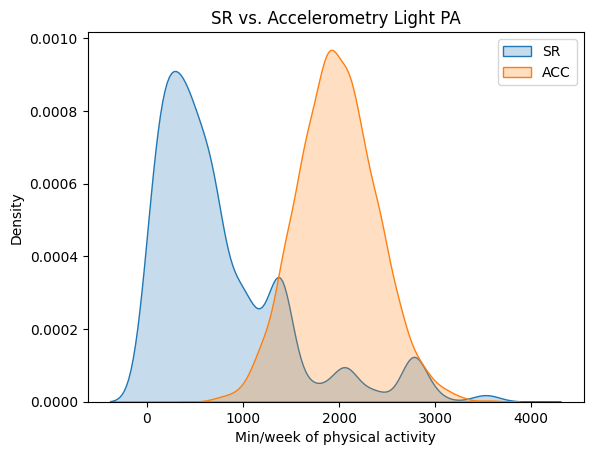

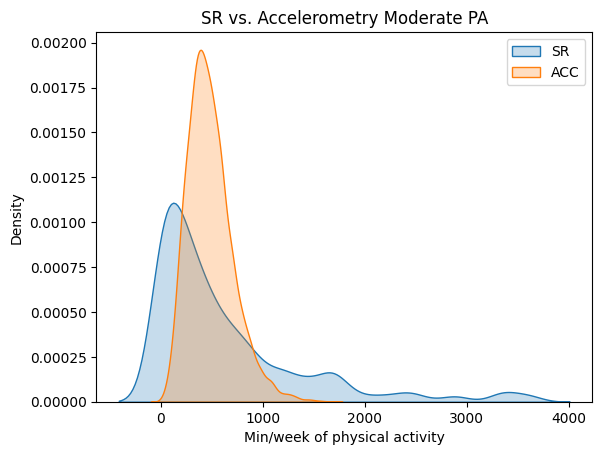

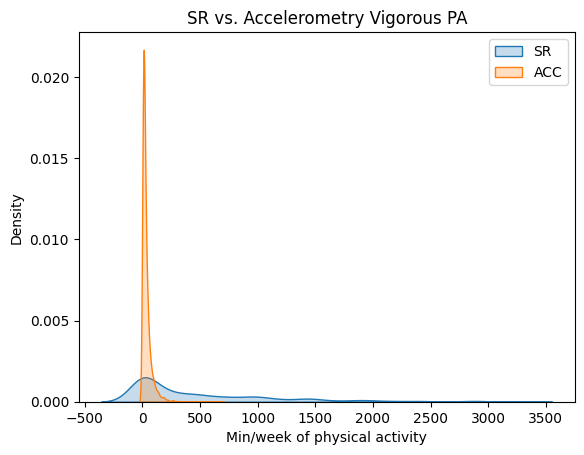

In [104]:
plt.figure()
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
sns.kdeplot(data = main_test, x= 'TPA', fill=True, label = "Total PA")
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.ylim(0,0.01)
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "Vigorous PA")
plt.xlabel("Min/week of physical activity")
plt.title("Self Report PA distributions")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR")
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "ACC")
plt.xlabel("Min/week of physical activity")
plt.title("SR vs. Accelerometry Light PA")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "ACC")
plt.xlabel("Min/week of physical activity")
plt.title("SR vs. Accelerometry Moderate PA")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "ACC")
plt.xlabel("Min/week of physical activity")
plt.title("SR vs. Accelerometry Vigorous PA")
plt.legend()
plt.show()

## 2.5 Fitness

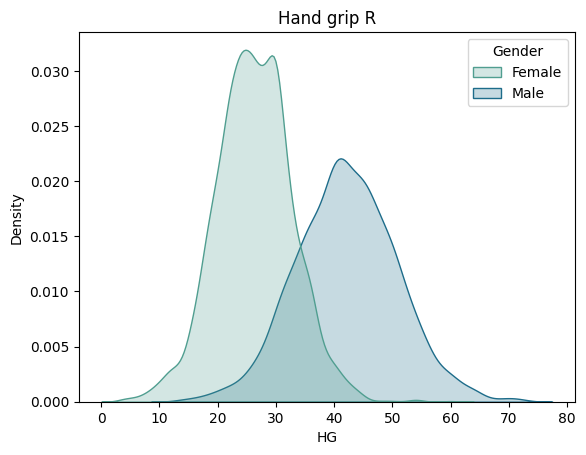

In [105]:
plt.figure()
sns.kdeplot(data = main_test, x= 'HG', hue = 'Gender', fill=True, palette = "crest")
plt.title("Hand grip R")
plt.show()

## 2.6 Health

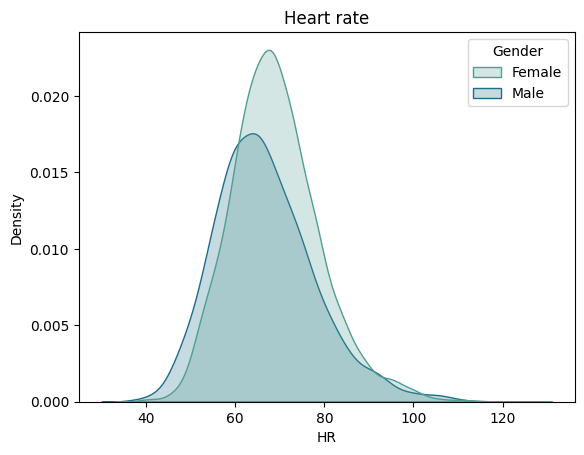

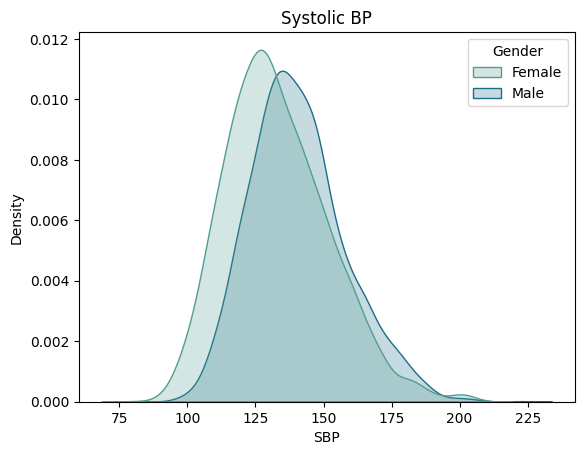

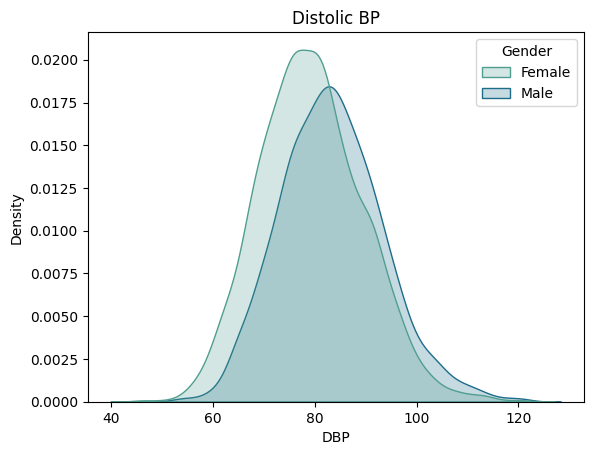

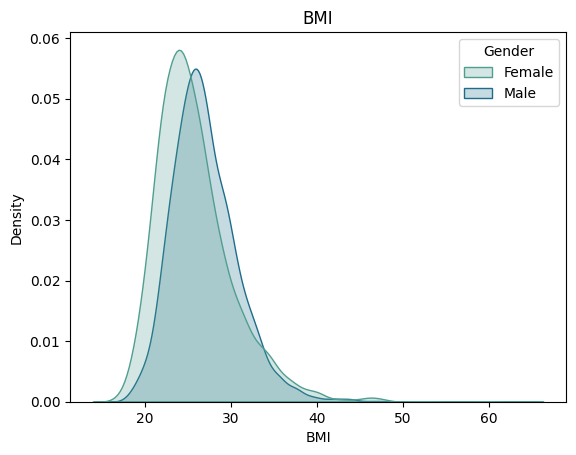

In [106]:
plt.figure()
sns.kdeplot(data = main_test, x= 'HR', hue = 'Gender', fill=True, palette = "crest")
plt.title("Heart rate")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Systolic BP")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'DBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Distolic BP")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'BMI', hue = 'Gender', fill=True, palette = "crest")
plt.title("BMI")
plt.show()

## 2.7 Other variables

Job PA: Never/rarely            2903
Sometimes                545
Usually                  101
Always                    54
Prefer not to answer       1
Do not know                0
Name: JPA, dtype: int64


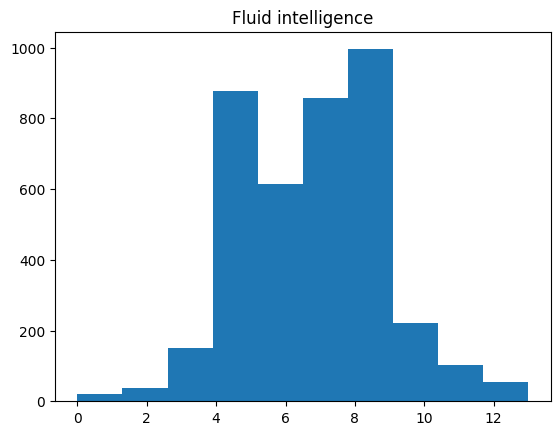

In [107]:
print("Job PA:", main_test["JPA"].value_counts())

plt.figure()
plt.hist(data = main_test, x= 'FI')
plt.title("Fluid intelligence")
plt.show()


# 3 Recode variables

In [108]:
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 1, '11026': 2,'11027': 3, '11028': 4})
main_test["Gender"] = main_test["Gender"].map({"Female":0, "Male":1})
main_test["Gender"] = main_test["Gender"].astype("int")
main_test["JPA"] = main_test["JPA"].map({"Never/rarely":0, "Sometimes":1, "Usually":2,"Always":3})

del main_test["ID"]
del main_test["BADDesikan"]
del main_test["BADASEG"]


main_test = main_test.rename(columns={"BADA2009": "BA"})

main_test = pd.DataFrame(main_test)
main_test = stats.zscore(main_test,nan_policy='omit')

# 4 Simple correlation heatmap

<AxesSubplot:>

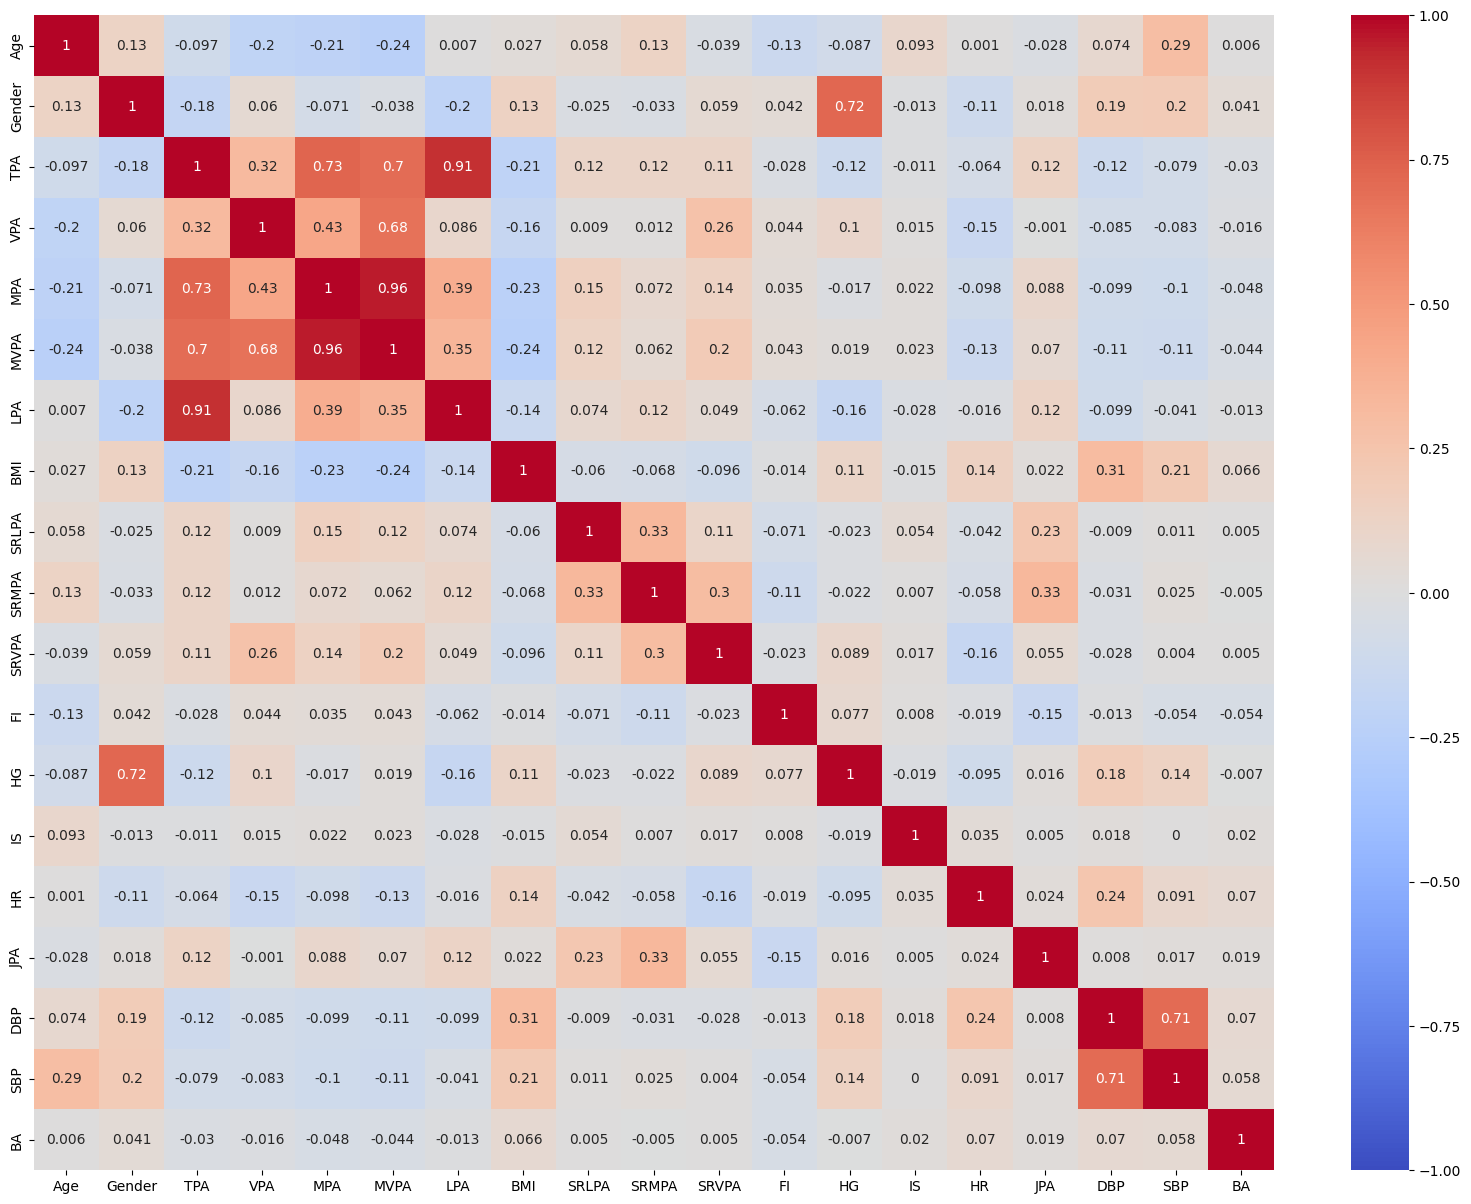

In [109]:
corr = main_test.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(20,15)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)

# 5 Partial correlations with Covariates

In [110]:
cov_correlation = pg.partial_corr(data=main_test, x='SRLPA', y='BA', covar=["Gender", "IS", "Age"])
print("SR Light PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='SRMPA', y='BA', covar=["Gender", "IS", "Age"])
print("SR Moderate PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='SRVPA', y='BA', covar=["Gender", "IS", "Age"])
print("SR Vigorous PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='TPA', y='BA', covar=["Gender", "IS", "Age"])
print("Total PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='LPA', y='BA', covar=["Gender", "IS", "Age"])
print("Light PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='MPA', y='BA', covar=["Gender", "IS", "Age"])
print("Moderate PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='VPA', y='BA', covar=["Gender", "IS", "Age"])
print("Vigorous PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='MVPA', y='BA', covar=["Gender", "IS", "Age"])
print("Moderate+Vigorous PA")
print(cov_correlation)

SR Light PA
            n        r          CI95%     p-val
pearson  5422  0.00504  [-0.02, 0.03]  0.710678
SR Moderate PA
            n        r          CI95%     p-val
pearson  5422 -0.00352  [-0.03, 0.02]  0.795582
SR Vigorous PA
            n         r          CI95%     p-val
pearson  5422  0.002623  [-0.02, 0.03]  0.846943
Total PA
            n         r         CI95%     p-val
pearson  5422 -0.023581  [-0.05, 0.0]  0.082608
Light PA
            n         r          CI95%     p-val
pearson  5422 -0.004308  [-0.03, 0.02]  0.751182
Moderate PA
            n         r           CI95%     p-val
pearson  5422 -0.047081  [-0.07, -0.02]  0.000526
Vigorous PA
            n         r          CI95%   p-val
pearson  5422 -0.019766  [-0.05, 0.01]  0.1457
Moderate+Vigorous PA
            n         r           CI95%     p-val
pearson  5422 -0.045044  [-0.07, -0.02]  0.000911


# 6 Models OLS

## 6.1 Covariates

In [111]:
cov_model = ols('BA ~ Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     5.383
Date:                Sun, 15 Jan 2023   Prob (F-statistic):           1.49e-05
Time:                        12:16:02   Log-Likelihood:                -7677.4
No. Observations:                5422   AIC:                         1.537e+04
Df Residuals:                    5415   BIC:                         1.541e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0062      0.014     -0.448      0.6

## 6.2 Accelerometer PA

In [112]:
pa_model = ols('BA ~ LPA + MPA + VPA + Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(pa_model.summary())

#calculate effect size
results = pa_model
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     5.083
Date:                Sun, 15 Jan 2023   Prob (F-statistic):           7.18e-07
Time:                        12:16:02   Log-Likelihood:                -7670.7
No. Observations:                5422   AIC:                         1.536e+04
Df Residuals:                    5412   BIC:                         1.543e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0060      0.014     -0.440      0.6

## 6.3 Self-report PA

In [113]:
sr_model = ols('BA ~ SRLPA + SRMPA + SRVPA +Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(sr_model.summary())

#calculate effect size
results = sr_model
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.624
Date:                Sun, 15 Jan 2023   Prob (F-statistic):           0.000160
Time:                        12:16:03   Log-Likelihood:                -7677.2
No. Observations:                5422   AIC:                         1.537e+04
Df Residuals:                    5412   BIC:                         1.544e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0061      0.014     -0.447      0.6

## 6.4 SR + Job PA + FI

In [114]:
sr_ex_model = ols('BA ~ SRLPA + SRMPA + SRVPA + FI + JPA + Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(sr_ex_model.summary())

#calculate effect size
results = sr_ex_model
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.668
Date:                Sun, 15 Jan 2023   Prob (F-statistic):            0.00208
Time:                        12:16:03   Log-Likelihood:                -3637.1
No. Observations:                2589   AIC:                             7298.
Df Residuals:                    2577   BIC:                             7369.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0427      0.021     -1.997      0.0

## 6.5 Accelerometer + Self-report PA

In [115]:
sr_pa_model = ols('BA ~ SRLPA + SRMPA + SRVPA +LPA + MPA + VPA+ Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(sr_pa_model.summary())

#calculate effect size
results = sr_pa_model
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.920
Date:                Sun, 15 Jan 2023   Prob (F-statistic):           4.89e-06
Time:                        12:16:03   Log-Likelihood:                -7670.0
No. Observations:                5422   AIC:                         1.537e+04
Df Residuals:                    5409   BIC:                         1.545e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0060      0.014     -0.436      0.6

## 6.6 PA + Fitness

In [116]:
pa_fitness = ols('BA ~ HG + LPA + MPA + VPA + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(pa_fitness.summary())

#calculate effect size
results = pa_fitness
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(7421))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     6.201
Date:                Sun, 15 Jan 2023   Prob (F-statistic):           1.72e-09
Time:                        12:16:03   Log-Likelihood:                -7662.6
No. Observations:                5422   AIC:                         1.535e+04
Df Residuals:                    5411   BIC:                         1.542e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0060      0.014     -0.439      0.6

## 6.7 Fitness

In [117]:
fitness = ols('BA ~ HG + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fitness.summary())

#calculate effect size
results = fitness
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     6.909
Date:                Sun, 15 Jan 2023   Prob (F-statistic):           3.30e-08
Time:                        12:16:03   Log-Likelihood:                -7669.4
No. Observations:                5422   AIC:                         1.535e+04
Df Residuals:                    5414   BIC:                         1.541e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0061      0.014     -0.447      0.6

## 6.8 Health

In [118]:
health = ols('BA ~ SBP + HR + DBP + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(health.summary())

#calculate effect size
results = health
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     8.408
Date:                Sun, 15 Jan 2023   Prob (F-statistic):           1.44e-12
Time:                        12:16:03   Log-Likelihood:                -7655.8
No. Observations:                5422   AIC:                         1.533e+04
Df Residuals:                    5412   BIC:                         1.540e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0066      0.014     -0.484      0.6

## 6.9 Health and Fitness

In [119]:
he_fi = ols('BA ~ HG + SBP + HR + DBP + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(he_fi.summary())

#calculate effect size
results = he_fi
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     9.417
Date:                Sun, 15 Jan 2023   Prob (F-statistic):           1.11e-15
Time:                        12:16:03   Log-Likelihood:                -7646.7
No. Observations:                5422   AIC:                         1.532e+04
Df Residuals:                    5411   BIC:                         1.539e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0066      0.014     -0.486      0.6

## 6.10 PA & Health

In [120]:
pa_he = ols('BA ~ LPA + MPA + VPA + SBP + HR + DBP + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(pa_he.summary())

#calculate effect size
results = pa_he
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     7.124
Date:                Sun, 15 Jan 2023   Prob (F-statistic):           4.77e-13
Time:                        12:16:03   Log-Likelihood:                -7651.0
No. Observations:                5422   AIC:                         1.533e+04
Df Residuals:                    5409   BIC:                         1.541e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0066      0.014     -0.479      0.6

## 6.11 PA + Health + Fitness

In [121]:
pa_he_fi = ols('BA ~ LPA + MPA + VPA + HG + SBP + HR + DBP + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(pa_he_fi.summary())

#calculate effect size
results = pa_he_fi
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     8.025
Date:                Sun, 15 Jan 2023   Prob (F-statistic):           3.56e-16
Time:                        12:16:03   Log-Likelihood:                -7641.7
No. Observations:                5422   AIC:                         1.531e+04
Df Residuals:                    5408   BIC:                         1.540e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0066      0.014     -0.481      0.6

## 6.12 Fluid intelligence

In [122]:
fi = ols('BA ~ FI + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fi.summary())

#calculate effect size
results = fi
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     4.099
Date:                Sun, 15 Jan 2023   Prob (F-statistic):           0.000171
Time:                        12:16:04   Log-Likelihood:                -5547.1
No. Observations:                3930   AIC:                         1.111e+04
Df Residuals:                    3922   BIC:                         1.116e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0122      0.016     -0.759      0.4

## 6.13 Fitness models

In [123]:
fit = ols('HG ~ LPA + MPA + VPA + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fit.summary())

#calculate effect size
results = fit
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     750.9
Date:                Sun, 15 Jan 2023   Prob (F-statistic):               0.00
Time:                        12:16:04   Log-Likelihood:                -5496.6
No. Observations:                5422   AIC:                         1.101e+04
Df Residuals:                    5412   BIC:                         1.108e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0003      0.009      0.029      0.9

In [124]:
fit2 = ols('HG ~ LPA + MPA + VPA + SRLPA + SRMPA + SRVPA + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fit2.summary())

#calculate effect size
results = fit2
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.556
Method:                 Least Squares   F-statistic:                     566.3
Date:                Sun, 15 Jan 2023   Prob (F-statistic):               0.00
Time:                        12:16:04   Log-Likelihood:                -5487.3
No. Observations:                5422   AIC:                         1.100e+04
Df Residuals:                    5409   BIC:                         1.109e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0002      0.009      0.024      0.9

# 7 Model comparisons

## 7.1 Cov x PA

In [125]:
model_comparison = anova_lm(cov_model, pa_model)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff         F    Pr(>F)
0    5415.0  5389.853383      0.0        NaN       NaN       NaN
1    5412.0  5376.548745      3.0  13.304637  4.464121  0.003888


In [126]:
model_comparison = anova_lm(cov_model, sr_model)
print(model_comparison)

   df_resid          ssr  df_diff   ss_diff         F    Pr(>F)
0    5415.0  5389.853383      0.0       NaN       NaN       NaN
1    5412.0  5389.516875      3.0  0.336508  0.112637  0.952743


## 7.2 Cov x PA x SR

In [127]:
model_comparison = anova_lm(pa_model, sr_pa_model)
print(model_comparison)

   df_resid          ssr  df_diff   ss_diff         F    Pr(>F)
0    5412.0  5376.548745      0.0       NaN       NaN       NaN
1    5409.0  5375.255396      3.0  1.293349  0.433823  0.728793


In [128]:
model_comparison = anova_lm(sr_model, sr_pa_model)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff        F    Pr(>F)
0    5412.0  5389.516875      0.0        NaN      NaN       NaN
1    5409.0  5375.255396      3.0  14.261479  4.78367  0.002485


## 7.3 SR x Job + FI

In [129]:
model_comparison = anova_lm(sr_model, sr_ex_model)
print(model_comparison)

   df_resid          ssr  df_diff      ss_diff         F    Pr(>F)
0    5412.0  5389.516875      0.0          NaN       NaN       NaN
1    2577.0  2516.976773   2835.0  2872.540102  1.037405  0.170285


## 7.4 Fitness models

In [130]:
model_comparison = anova_lm(fit, fit2)
print(model_comparison)

   df_resid          ssr  df_diff   ss_diff        F    Pr(>F)
0    5412.0  2411.192120      0.0       NaN      NaN       NaN
1    5409.0  2402.905707      3.0  8.286413  6.21764  0.000327


## 7.5 Health x Fitness x PA

In [131]:
model_comparison = anova_lm(pa_model, pa_fitness)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff          F   Pr(>F)
0    5412.0  5376.548745      0.0        NaN        NaN      NaN
1    5411.0  5360.564514      1.0  15.984232  16.134621  0.00006


In [132]:
model_comparison = anova_lm(pa_model, pa_he)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff          F        Pr(>F)
0    5412.0  5376.548745      0.0        NaN        NaN           NaN
1    5409.0  5337.645349      3.0  38.903396  13.141155  1.511025e-08


In [133]:
model_comparison = anova_lm(pa_model, pa_he_fi)
print(model_comparison)

   df_resid          ssr  df_diff   ss_diff          F        Pr(>F)
0    5412.0  5376.548745      0.0       NaN        NaN           NaN
1    5408.0  5319.381326      4.0  57.16742  14.529951  8.322995e-12


# 8 Mediation analysis

## 8.1 PA x Health / Fitness

### 8.1.1 BMI

In [134]:
#regression of x on m
model1 = ols('BMI ~ LPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ BMI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ LPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['LPA'] * model2.params['BMI']
#calculate the total effect
total_effect = model3.params['LPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.009009481959080213
Direct effect: -0.004209242902667935
Total effect: -0.013218724861748148


In [135]:
#regression of x on m
model1 = ols('BMI ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ BMI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['MPA'] * model2.params['BMI']
#calculate the total effect
total_effect = model3.params['MPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.01539071605396008
Direct effect: -0.032675751775302665
Total effect: -0.04806646782926274


In [136]:
#regression of x on m
model1 = ols('BMI ~ VPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ BMI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ VPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['VPA'] * model2.params['BMI']
#calculate the total effect
total_effect = model3.params['VPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.010725862620733344
Direct effect: -0.005531665087158586
Total effect: -0.01625752770789193


### 8.1.2 DBP

In [137]:
#regression of x on m
model1 = ols('DBP ~ LPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ DBP',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ LPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['LPA'] * model2.params['DBP']
#calculate the total effect
total_effect = model3.params['LPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.006955931718424471
Direct effect: -0.006262793143323677
Total effect: -0.013218724861748148


In [138]:
#regression of x on m
model1 = ols('DBP ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ DBP',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['MPA'] * model2.params['DBP']
#calculate the total effect
total_effect = model3.params['MPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.006978894807053826
Direct effect: -0.04108757302220892
Total effect: -0.04806646782926274


In [139]:
#regression of x on m
model1 = ols('DBP ~ VPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ DBP',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ VPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['VPA'] * model2.params['DBP']
#calculate the total effect
total_effect = model3.params['VPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.005945657479546743
Direct effect: -0.010311870228345187
Total effect: -0.01625752770789193


### 8.1.3 Heart rate

In [140]:
#regression of x on m
model1 = ols('HR ~ LPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HR',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ LPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['LPA'] * model2.params['HR']
#calculate the total effect
total_effect = model3.params['LPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.0011543109364188214
Direct effect: -0.012064413925329327
Total effect: -0.013218724861748148


In [141]:
#regression of x on m
model1 = ols('HR ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HR',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['MPA'] * model2.params['HR']
#calculate the total effect
total_effect = model3.params['MPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.0068933294101957455
Direct effect: -0.041173138419067
Total effect: -0.04806646782926274


In [142]:
#regression of x on m
model1 = ols('HR ~ VPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HR',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ VPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['VPA'] * model2.params['HR']
#calculate the total effect
total_effect = model3.params['VPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.010402761249800737
Direct effect: -0.0058547664580911925
Total effect: -0.01625752770789193


### 8.1.4 Hand grip

In [143]:
#regression of x on m
model1 = ols('HG ~ LPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HG',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ LPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['LPA'] * model2.params['HG']
#calculate the total effect
total_effect = model3.params['LPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: 0.001079918333614989
Direct effect: -0.014298643195363137
Total effect: -0.013218724861748148


In [144]:
#regression of x on m
model1 = ols('HG ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HG',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['MPA'] * model2.params['HG']
#calculate the total effect
total_effect = model3.params['MPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: 0.00011217062687044411
Direct effect: -0.04817863845613319
Total effect: -0.04806646782926274


In [145]:
#regression of x on m
model1 = ols('HG ~ VPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HG',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ VPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['VPA'] * model2.params['HG']
#calculate the total effect
total_effect = model3.params['VPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.0006803483897743504
Direct effect: -0.01557717931811758
Total effect: -0.01625752770789193


## 8.2 SR PA x Job PA / Fluid intelligence

In [146]:
#regression of x on m
model1 = ols('FI ~ SRLPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ FI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ SRLPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['SRLPA'] * model2.params['FI']
#calculate the total effect
total_effect = model3.params['SRLPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: 0.0037685447809742193
Direct effect: 0.001259766820651867
Total effect: 0.005028311601626086


In [147]:
#regression of x on m
model1 = ols('FI ~ SRMPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ FI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ SRMPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['SRMPA'] * model2.params['FI']
#calculate the total effect
total_effect = model3.params['SRMPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: 0.00611700774795282
Direct effect: -0.01098185334642634
Total effect: -0.00486484559847352


In [148]:
#regression of x on m
model1 = ols('FI ~ SRVPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ FI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ SRVPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['SRVPA'] * model2.params['FI']
#calculate the total effect
total_effect = model3.params['SRVPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: 0.0012303888500991963
Direct effect: 0.0041920584133672174
Total effect: 0.005422447263466414


In [149]:
#regression of x on m
model1 = ols('FI ~ JPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ FI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ JPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['JPA'] * model2.params['FI']
#calculate the total effect
total_effect = model3.params['JPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: 0.008112641246458056
Direct effect: 0.010960722130953986
Total effect: 0.019073363377412042


# 9 LASSO Regression

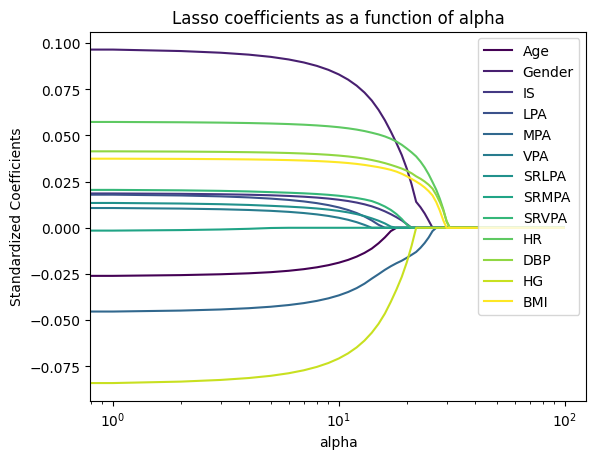

In [150]:
df = main_test[["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))
plt.xticks(alphas)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('Standardized Coefficients')
plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")

# 10 Figures for Paper

## 10.1 Smaller Correlation Heatmap

<AxesSubplot:>

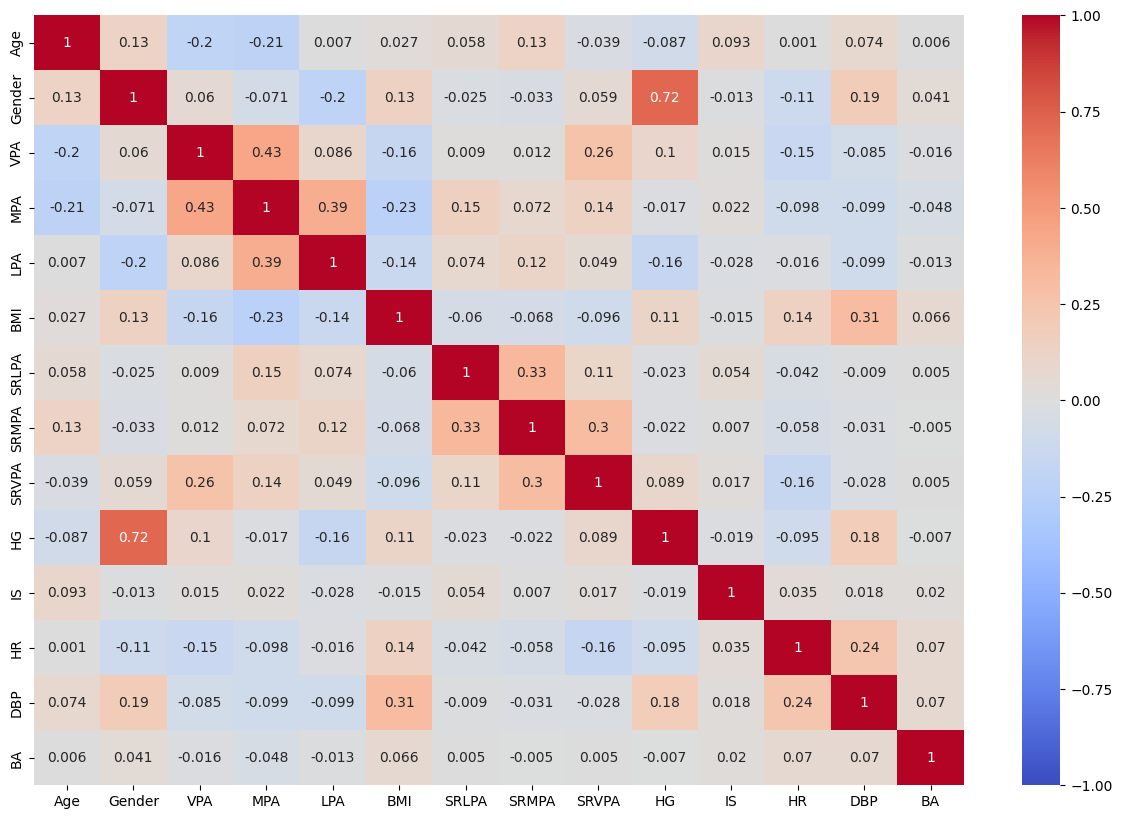

In [151]:
x = main_test
del x["SBP"]
del x["TPA"]
del x["MVPA"]
del x["FI"]
del x["JPA"]
corr = x.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(15,10)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)


# 11 Exploration vs. Validation

## 11.1 Import processed Validation set

In [152]:
validate = pd.read_pickle("3_validate.pkl")
validate = pd.DataFrame(validate)

## 11.2 BrainAGE distribution

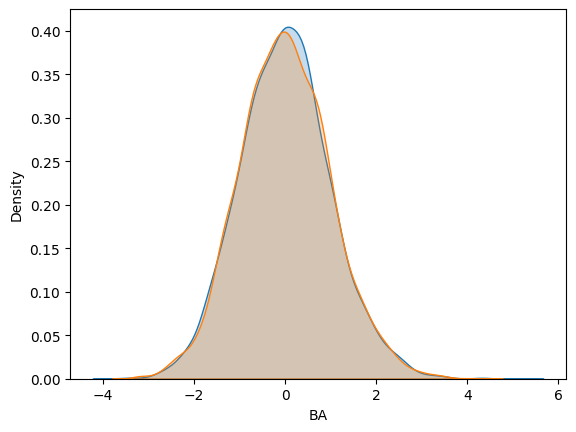

In [153]:
plt.figure()
sns.kdeplot(data = validate, x= 'BA', fill=True, label = "Validate")
sns.kdeplot(data = main_test, x= 'BA', fill=True, label = "Explore")
plt.show()

## 11.3 MPA distribution

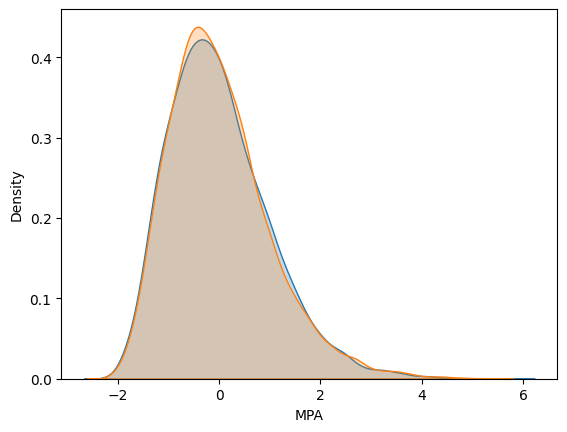

In [154]:
plt.figure()
sns.kdeplot(data = validate, x= 'MPA', fill=True, label = "Validate")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Explore")
plt.show()